In [1]:
import numpy as np
import mdtraj as md
from docking_tools import trajectory_analysis 
from docking_tools import plotting
import pandas as pd

In [2]:

# Load the Filtered Frame Indices ---
# Load the CSV for Ligand 47 (Negative values only)
cleaned_csv = '/home/zhihanz/data/smina/negative_only_results/47_charged_negative.csv'
df_valid = pd.read_csv(cleaned_csv)

valid_frames_set = set(df_valid['Frame'].astype(int).tolist())

#  Load the Full Trajectory ---
traj_file = '/home/zhihanz/data/DiffDock_copy/py_scripts/47_apo_whole_traj_charged.xtc'
pdb = '/home/zhihanz/data/DiffDock_copy/py_scripts/47_h/47_apo_complex_frame_00001_H.pdb'
whole_traj = md.load(traj_file, top=pdb)

# Split into Clusters (This part should be changed after) ---
clus_idx = np.insert(np.cumsum(np.loadtxt('/home/zhihanz/data/DiffDock_copy/data/anjali/ligand47/DiffDock_apo_clus_count.txt')), 0, 0)

trajs = [whole_traj[int(clus_idx[i]):int(clus_idx[i+1])] for i in range(len(clus_idx)-1)]

# FILTER LIGAND-BY-LIGAND (Within each cluster) ---
filtered_trajs = []

for i, cluster_traj in enumerate(trajs):
    start_frame = int(clus_idx[i])
    end_frame = int(clus_idx[i+1])
    
    keep_indices = [
        local_idx for local_idx in range(cluster_traj.n_frames) 
        if (start_frame + local_idx) in valid_frames_set
    ]
    
    if keep_indices:
        filtered_cluster = cluster_traj[keep_indices]
        filtered_trajs.append(filtered_cluster)
        print(f"Cluster {i}: Kept {filtered_cluster.n_frames} / {cluster_traj.n_frames} frames")
    else:
        print(f"Cluster {i}: No negative affinity frames found.")
        filtered_trajs.append(None)

Cluster 0: Kept 514 / 1001 frames
Cluster 1: Kept 541 / 1001 frames
Cluster 2: Kept 517 / 1001 frames
Cluster 3: Kept 543 / 1001 frames
Cluster 4: Kept 567 / 1001 frames
Cluster 5: Kept 562 / 1001 frames
Cluster 6: Kept 535 / 1001 frames
Cluster 7: Kept 500 / 1001 frames
Cluster 8: Kept 543 / 1001 frames
Cluster 9: Kept 524 / 1001 frames
Cluster 10: Kept 504 / 1001 frames
Cluster 11: Kept 465 / 1001 frames
Cluster 12: Kept 535 / 1001 frames
Cluster 13: Kept 416 / 1001 frames
Cluster 14: Kept 518 / 1001 frames
Cluster 15: Kept 128 / 287 frames
Cluster 16: No negative affinity frames found.
Cluster 17: No negative affinity frames found.
Cluster 18: No negative affinity frames found.
Cluster 19: No negative affinity frames found.


In [4]:
# These are from Anjali's code

n_clus = len(clus_idx) - 1

n_frames_per_clus = [t.n_frames if t is not None else 0 for t in filtered_trajs]

first_valid_traj = next(t for t in filtered_trajs if t is not None)
n_res = first_valid_traj.top.select('protein').shape[0]
ligand_idx = n_res 

weights = np.load('weights_apo.npy')


In [6]:
contacts = {key: [] for key in ['hphob', 'aro', 'hbond', 'charge', 'dual']}

LIGAND_RESID    = 20
RING_BENZENE    = [300, 301, 302, 303, 304, 305]
LIG_HBOND_DONORS = [[296, 329], [313, 351]]
LIG_POS_CHARGES  = [313]


first_valid_traj = next(
    whole_traj[int(clus_idx[i]):int(clus_idx[i+1])]
    for i in range(n_clus)
    if sum(1 for idx in range(int(clus_idx[i+1])-int(clus_idx[i]))
           if (int(clus_idx[i])+idx) in valid_frames_set) > 0
)
protein_top = first_valid_traj.atom_slice(
    first_valid_traj.top.select('protein')).topology
n_res = protein_top.n_residues
res_labels = [f"{res.name}{res.resSeq}"
              for res in first_valid_traj.top.residues
              if res.is_protein]
print(f"n_res = {n_res}, labels = {res_labels}")


for i in range(n_clus):
    start, end = int(clus_idx[i]), int(clus_idx[i+1])
    cluster_traj = whole_traj[start:end]
    keep_indices = [idx for idx in range(cluster_traj.n_frames)
                    if (start + idx) in valid_frames_set]

    if not keep_indices:
        print(f"Cluster {i}: skipped (no valid frames)")
        for key in contacts:
            contacts[key].append(None)
        continue

    t = cluster_traj[keep_indices]
    print(f"Cluster {i}: {t.n_frames} frames", end=" | ")

    try:
        hp = trajectory_analysis.hphob_contacts(t, LIGAND_RESID)
        contacts['hphob'].append(hp)
        print(f"hphob={hp.sum(axis=1).mean():.3f}", end=" | ")
    except Exception as e:
        print(f"hphob ERR:{e}", end=" | ")
        contacts['hphob'].append(np.zeros((t.n_frames, n_res)))

    try:
        ar = trajectory_analysis.aro_contacts(
                t, ligand_rings=[ RING_BENZENE])
        contacts['aro'].append(ar)
        print(f"aro={ar.sum(axis=1).mean():.3f}", end=" | ")
    except Exception as e:
        print(f"aro ERR:{e}", end=" | ")
        contacts['aro'].append(np.zeros((t.n_frames, n_res)))

    try:
        hb = trajectory_analysis.hbond(
                t, LIGAND_RESID, lig_hbond_donors=LIG_HBOND_DONORS)
        contacts['hbond'].append(hb)
        print(f"hbond={hb.sum(axis=1).mean():.3f}", end=" | ")
    except Exception as e:
        print(f"hbond ERR:{e}", end=" | ")
        contacts['hbond'].append(np.zeros((t.n_frames, n_res)))

    try:
        ch = trajectory_analysis.charge_contacts(
                t, Ligand_Pos_Charges=LIG_POS_CHARGES,
                   )
        contacts['charge'].append(ch)
        print(f"charge={ch.sum(axis=1).mean():.3f}", end=" | ")
    except Exception as e:
        print(f"charge ERR:{e}", end=" | ")
        contacts['charge'].append(np.zeros((t.n_frames, n_res)))

    try:
        du = trajectory_analysis.dual_contact(t, residue_idx=LIGAND_RESID)
        contacts['dual'].append(du)
    except Exception as e:
        contacts['dual'].append(None)

    print()

# Maybe we don't need the weights for the filtered results
weights_1d = weights.flatten()

contact_probs = {}
for key in ['hphob', 'aro', 'hbond', 'charge']:
    valid = [(i, arr) for i, arr in enumerate(contacts[key])
             if arr is not None]
    valid_indices, valid_arrs = zip(*valid)

    per_clus_mean = np.array([arr[:, :n_res].mean(axis=0)
                               for arr in valid_arrs])
    w = weights_1d[list(valid_indices)]
    w = w / w.sum()
    contact_probs[key] = np.average(per_clus_mean, axis=0, weights=w)
    print(f"{key}: max={contact_probs[key].max():.4f}, "
          f"nonzero={(contact_probs[key]>0.01).sum()}/{n_res} residues")

n_res = 20, labels = ['ASP121', 'ASN122', 'GLU123', 'ALA124', 'TYR125', 'GLU126', 'MET127', 'PRO128', 'SER129', 'GLU130', 'GLU131', 'GLY132', 'TYR133', 'GLN134', 'ASP135', 'TYR136', 'GLU137', 'PRO138', 'GLU139', 'ALA140']
Cluster 0: 514 frames | hphob=2.204 | aro=0.103 | hbond=0.444 | charge=0.189 | 
Cluster 1: 541 frames | hphob=2.253 | aro=0.109 | hbond=0.471 | charge=0.185 | 
Cluster 2: 517 frames | hphob=2.373 | aro=0.097 | hbond=0.503 | charge=0.164 | 
Cluster 3: 543 frames | hphob=2.208 | aro=0.087 | hbond=0.444 | charge=0.160 | 
Cluster 4: 567 frames | hphob=2.199 | aro=0.108 | hbond=0.459 | charge=0.159 | 
Cluster 5: 562 frames | hphob=2.399 | aro=0.107 | hbond=0.553 | charge=0.178 | 
Cluster 6: 535 frames | hphob=2.424 | aro=0.118 | hbond=0.538 | charge=0.159 | 
Cluster 7: 500 frames | hphob=2.294 | aro=0.088 | hbond=0.522 | charge=0.170 | 
Cluster 8: 543 frames | hphob=2.495 | aro=0.144 | hbond=0.564 | charge=0.131 | 
Cluster 9: 524 frames | hphob=2.448 | aro=0.134 | hbond=0.

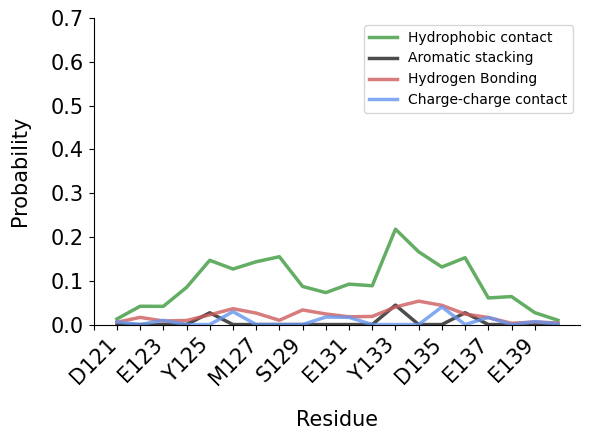

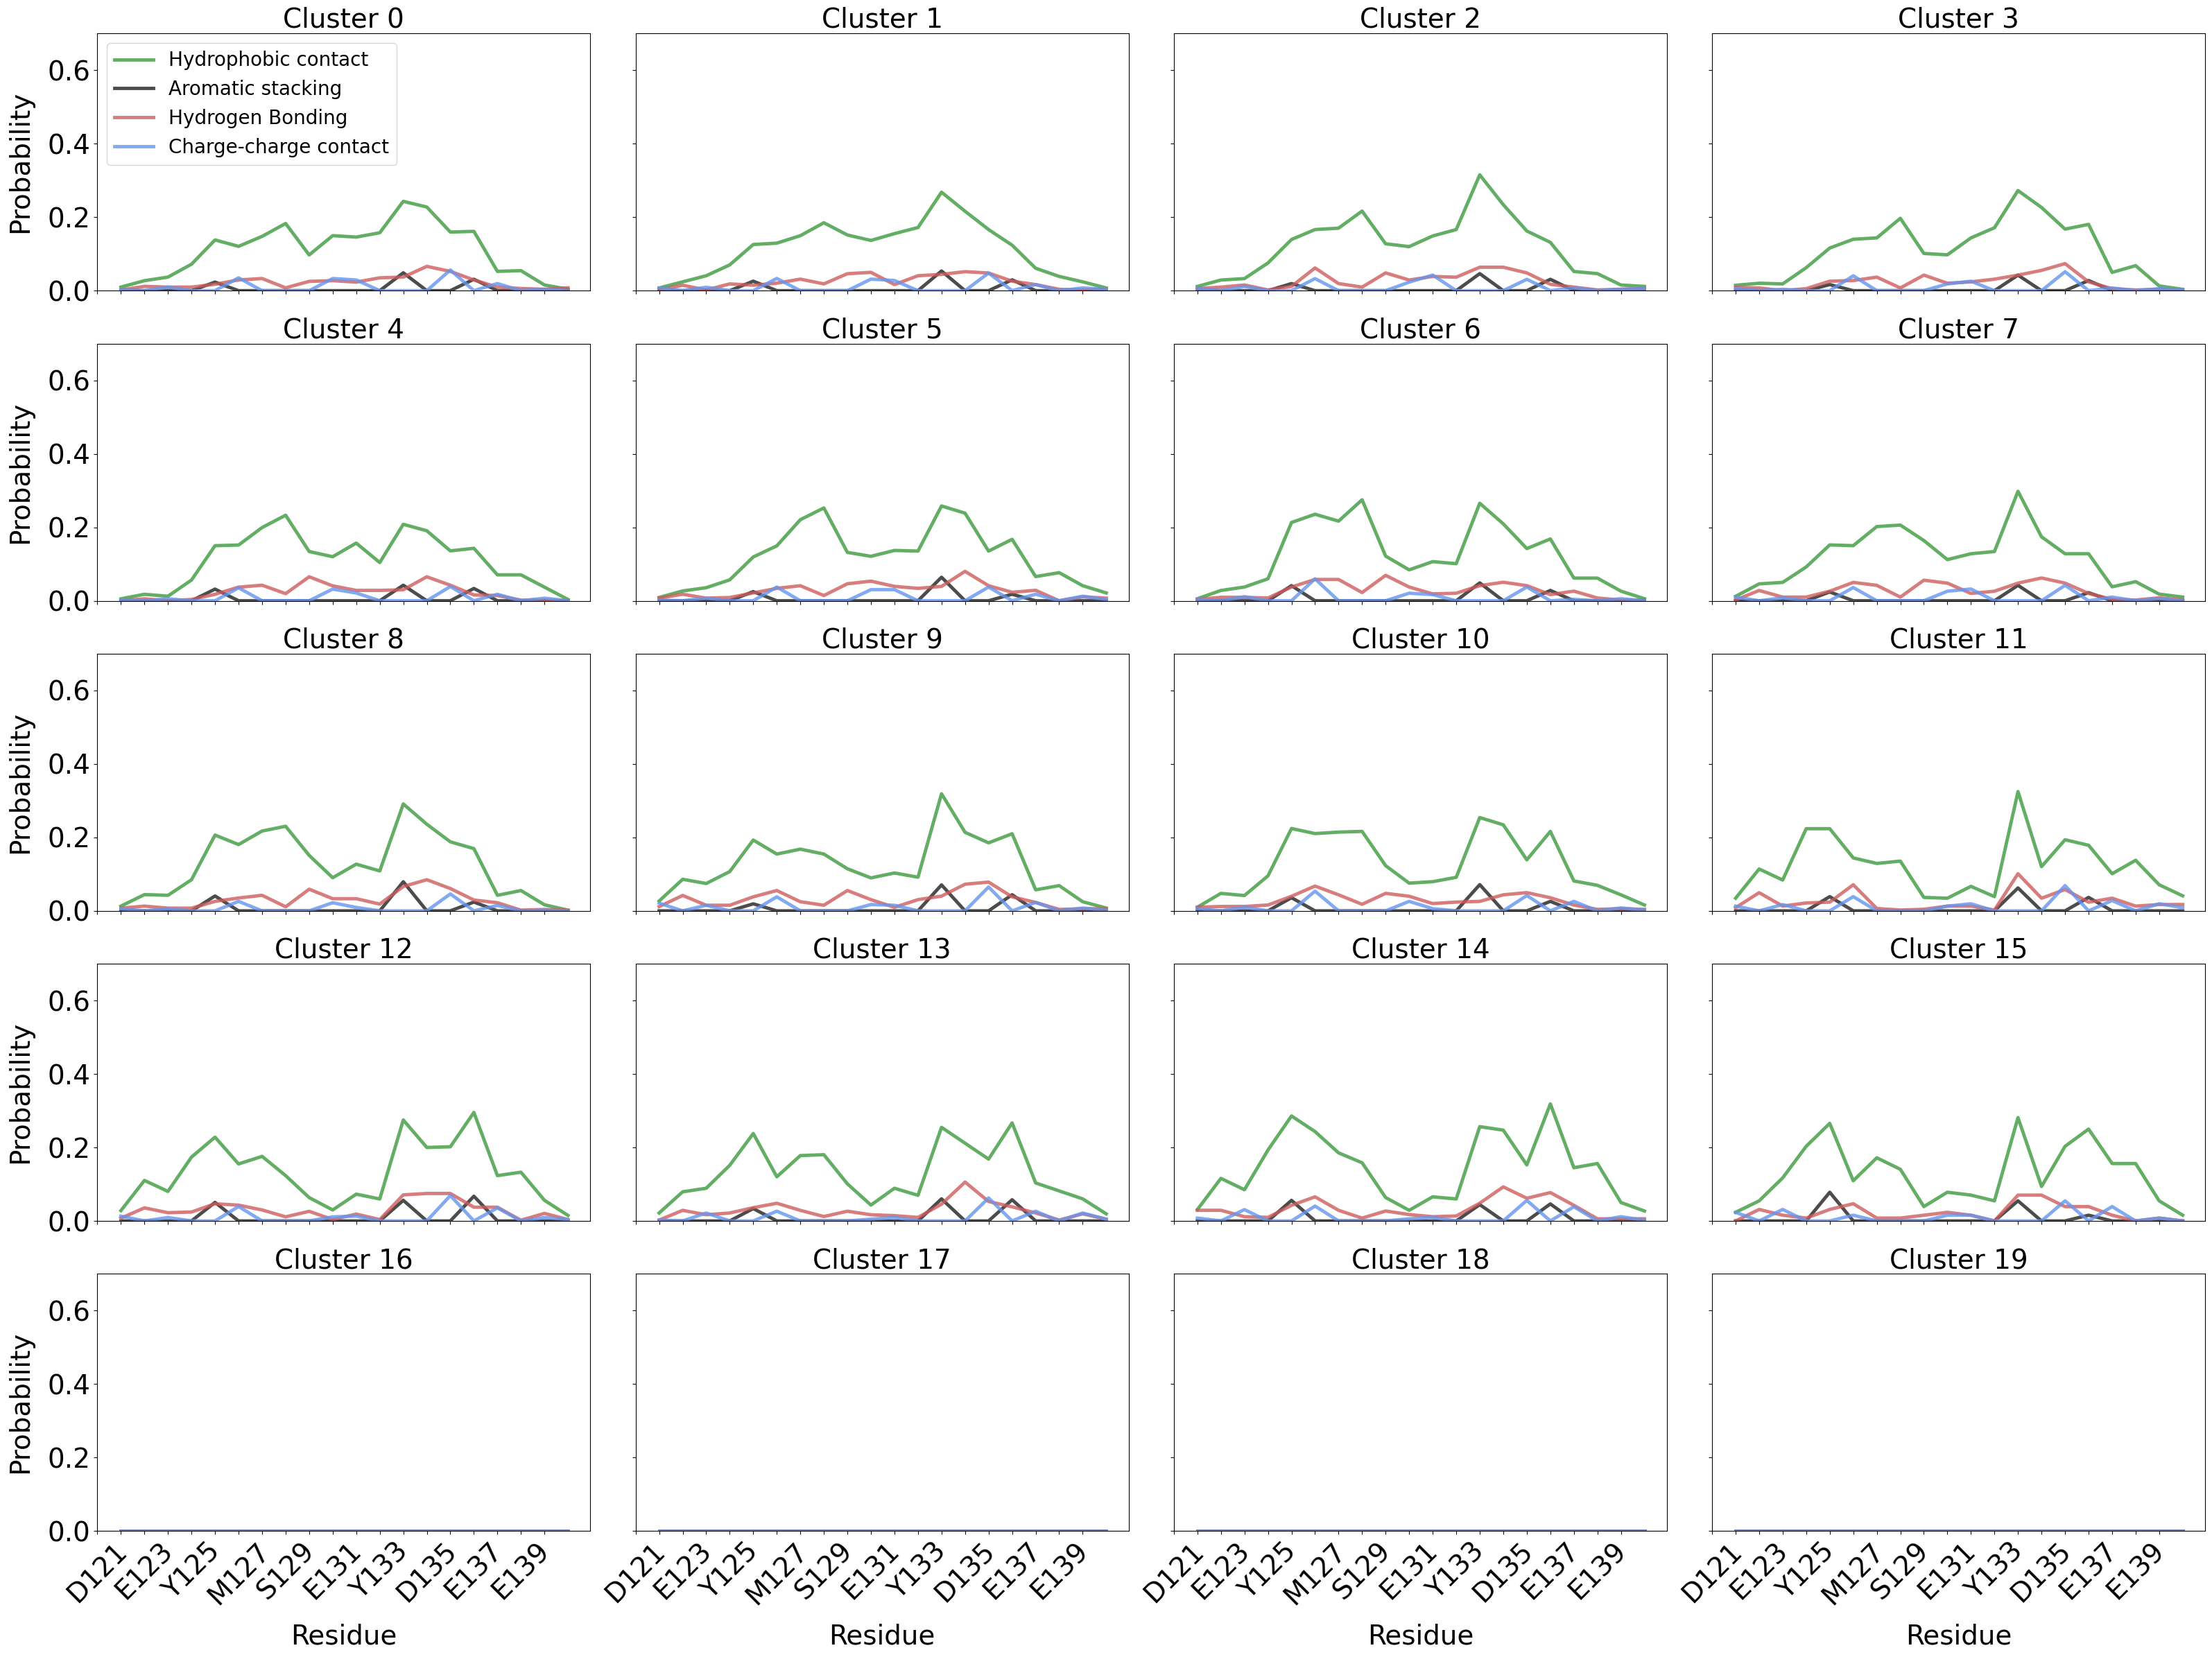

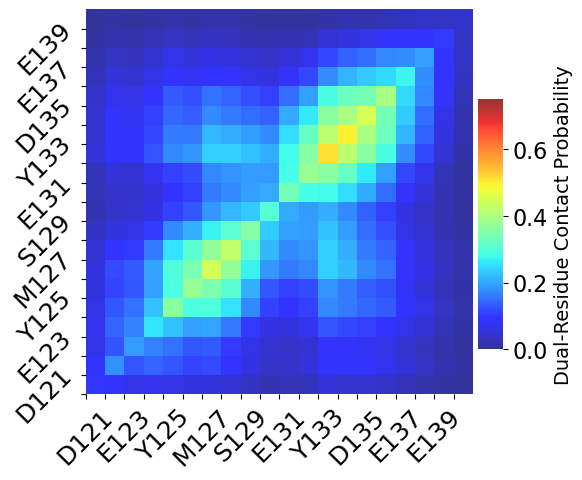

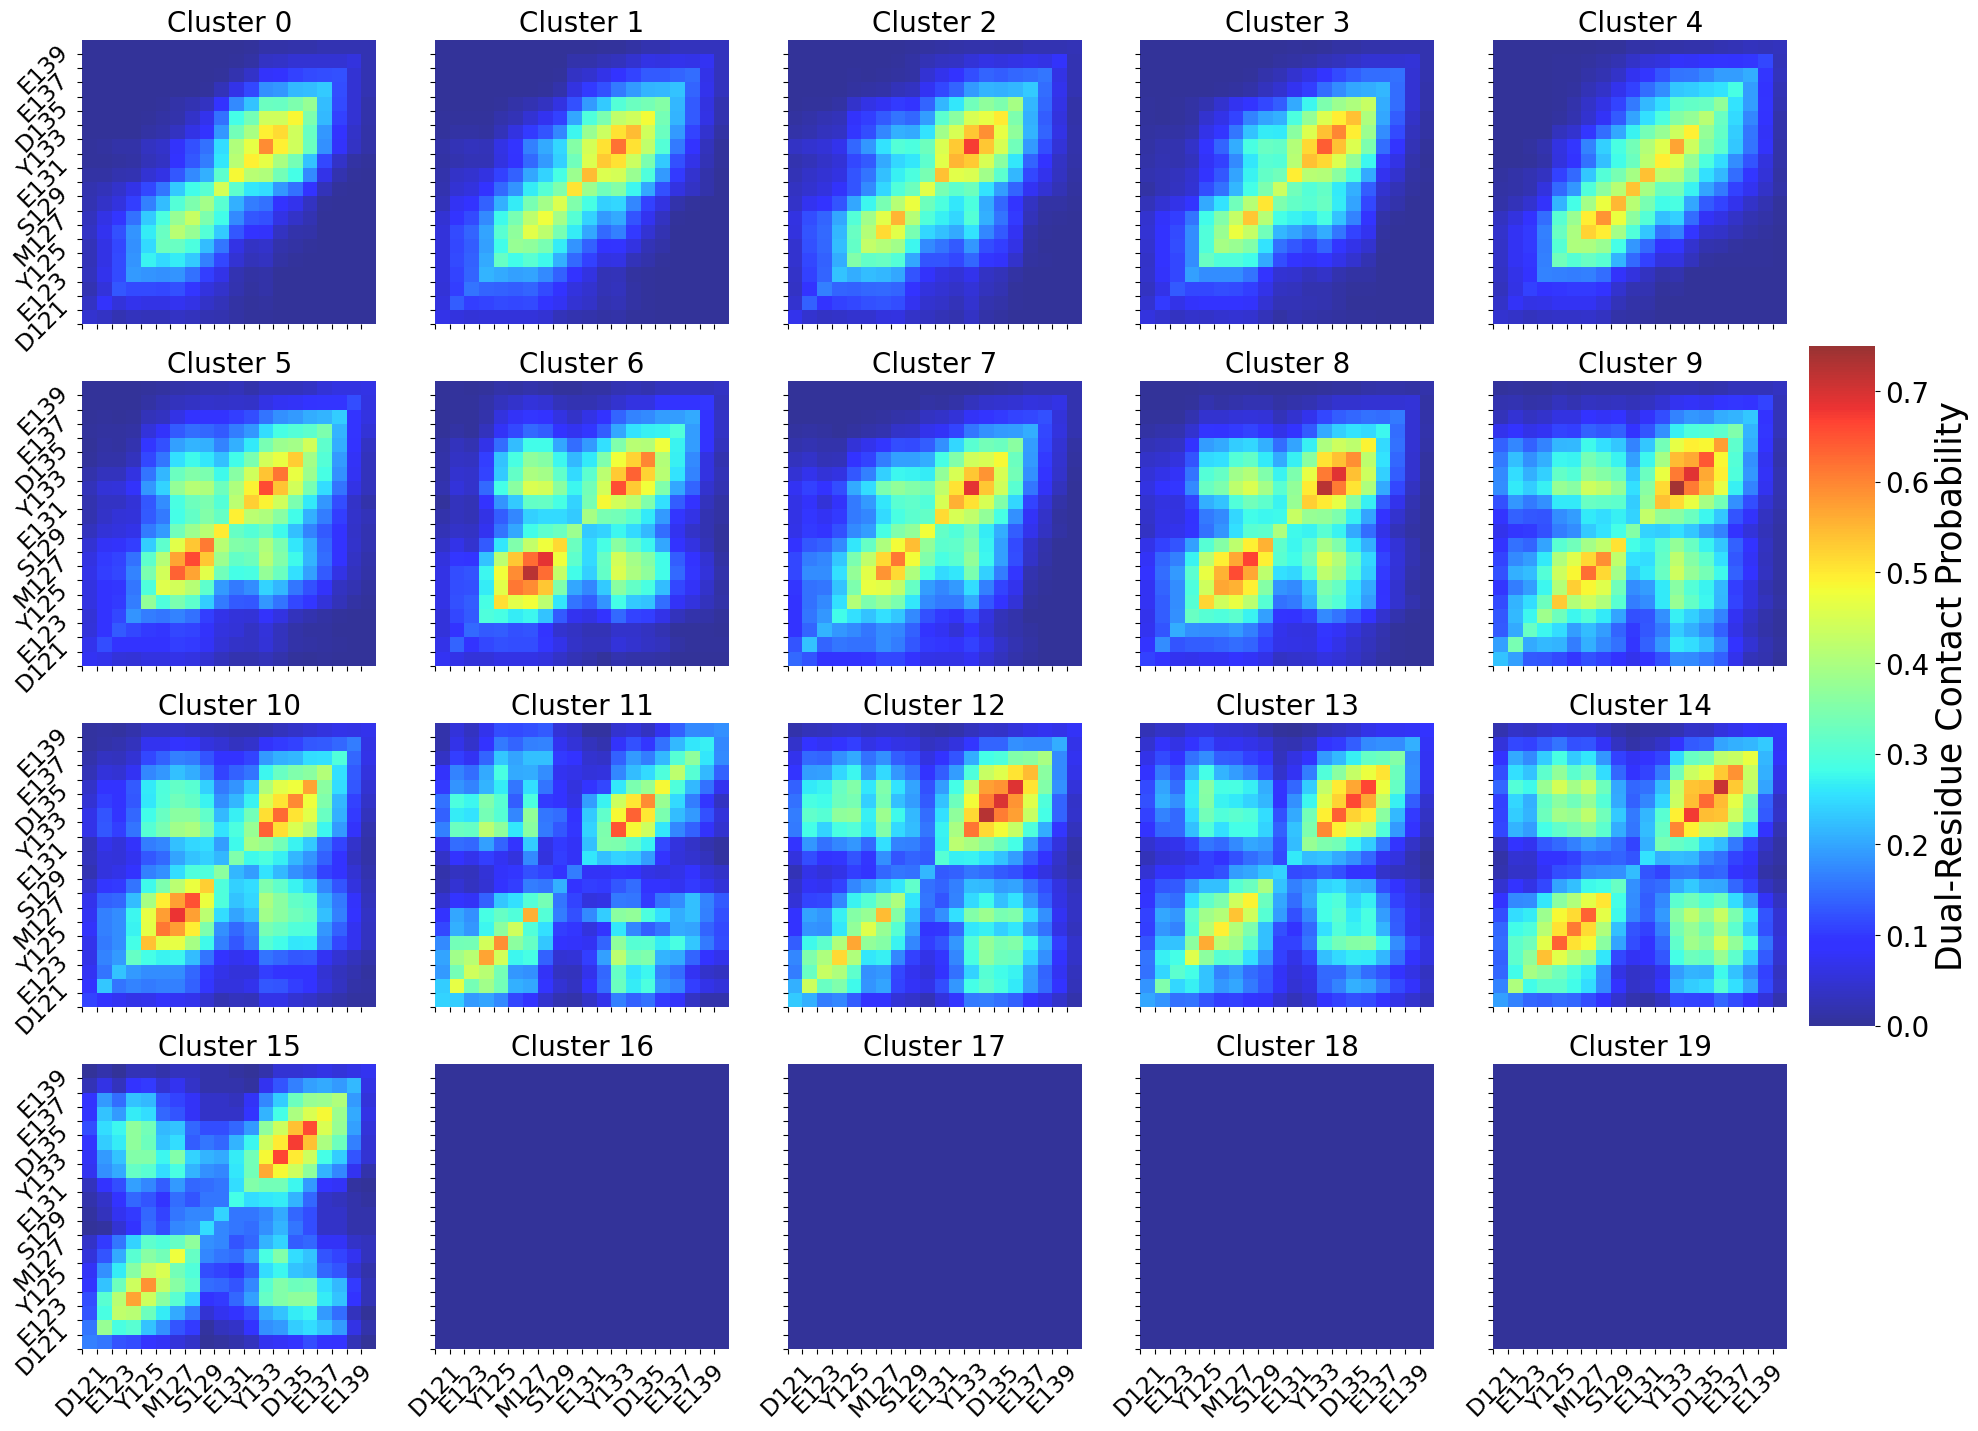

In [7]:
# Plot

contacts_plot = {}
for key in ['hphob', 'aro', 'hbond', 'charge']:
    per_clus_means = []
    for arr in contacts[key]:
        if arr is None:
            per_clus_means.append(np.zeros(20))
        else:
            per_clus_means.append(arr[:, :20].mean(axis=0))  # (20,)
    contacts_plot[key] = np.array(per_clus_means)[:, np.newaxis, :]  # (n_clus, 1, 20)


contacts_plot['dual'] = np.array([
    arr if arr is not None else np.zeros((20, 20))
    for arr in contacts['dual']
])

plotting.plot_ensemble_ii(contacts_plot, weights)
plt.savefig('ensemble_ii_ligand47.png', dpi=150, bbox_inches='tight')
plt.show()


plotting.plot_clus_ii(contacts_plot)
plt.savefig('clus_ii_ligand47.png', dpi=150, bbox_inches='tight')
plt.show()

plotting.plot_ensemble_dual(contacts_plot['dual'], weights)
plt.savefig('ensemble_dual_ligand47.png', dpi=150, bbox_inches='tight')
plt.show()

plotting.plot_clus_dual(contacts_plot['dual'])
plt.savefig('clus_dual_ligand47.png', dpi=150, bbox_inches='tight')
plt.show()



In [12]:
import os
from scipy.stats import gaussian_kde

desres_dir = '/home/zhihanz/data/MDdata/DESRES-Trajectory_biorxiv2021-6626290-no-water-glue/biorxiv2021-6626290-no-water-glue'
desres_top = os.path.join(desres_dir, 'top_from_local_mae.pdb')

dcd_files = sorted(glob.glob(
    os.path.join(desres_dir, 
                 'biorxiv2021-6626290-no-water-glue-*.dcd')))
dcd_files = [f for f in dcd_files if 'traj_all' not in f]
desres_traj = md.load(dcd_files, top=desres_top)


traj_file = '/home/zhihanz/data/DiffDock_copy/py_scripts/47_apo_whole_traj_charged.xtc'
pdb       = '/home/zhihanz/data/DiffDock_copy/py_scripts/47_h/47_apo_complex_frame_00001_H.pdb'

query_traj = md.load(traj_file, top=pdb)

cleaned_csv      = '/home/zhihanz/data/smina/negative_only_results/47_charged_negative.csv'
df_valid         = pd.read_csv(cleaned_csv)
valid_frames_set = set(df_valid['Frame'].astype(int).tolist())
valid_indices    = sorted([i for i in range(query_traj.n_frames)
                            if i in valid_frames_set])
query_filtered   = query_traj[valid_indices]
print(f"Query (filtered, affinity<0): {query_filtered.n_frames} frames "
      f"({query_filtered.n_frames/query_traj.n_frames*100:.1f}%)")

Query (filtered, affinity<0): 7912 frames (51.7%)


In [21]:
q_ca        = query_filtered.top.select('backbone and resid 0 to 19')
q_lig_heavy = query_filtered.top.select('resid 20 and not element H')

desres_ca        = desres_traj.top.select('backbone and resid 0 to 19')
desres_bb        = desres_traj.top.select('backbone and resid 0 to 19')
desres_lig_heavy = desres_traj.top.select('resid 21 and not element H')
desres_prot_heavy= desres_traj.top.select('resid 0 to 19 and not element H')

STRIDE_CONTACT = 100
desres_sample  = desres_traj[::STRIDE_CONTACT]

min_dist_sample = np.zeros((desres_sample.n_frames, 20))
for res_idx in range(20):
    prot_atoms = desres_traj.top.select(
        f'resid {res_idx} and not element H')
    pairs = np.array([[p, l] for p in prot_atoms
                              for l in desres_lig_heavy])
    dists = md.compute_distances(desres_sample, pairs) * 10
    min_dist_sample[:, res_idx] = dists.min(axis=1)

contact_freq = (min_dist_sample < 6.0).mean(axis=0) * 100
contact_res  = [i for i in range(20) if contact_freq[i] > 30.0]
resid_sel    = ' '.join(str(r) for r in contact_res)

res_labels_desres = [f"{res.name}{res.resSeq}"
                     for res in desres_traj.top.residues
                     if res.is_protein and res.index < 20]
print(f"Contact residues (>30% frames at 6Å): "
      f"{[res_labels_desres[i] for i in contact_res]}")

align_m2_d = desres_traj.top.select(f'backbone and resid {resid_sel}')
align_m3_d = desres_traj.top.select(
    f'resid {resid_sel} and not element H')
align_m2_q = query_filtered.top.select(f'backbone and resid {resid_sel}')
align_m3_q = query_filtered.top.select(
    f'resid {resid_sel} and not element H')

print(f"\nAlignment atoms:")
print(f"  M1 (Full backbone):               {len(desres_ca)}")
print(f"  M2 (contact backbone): {len(align_m2_d)}")
print(f"  M3 (contact heavy):    {len(align_m3_d)}")

STRIDE_DESRES = 500
n_clus        = 20
desres_n      = desres_traj.n_frames
clus_size     = desres_n // n_clus
desres_cidx   = np.array([i * clus_size for i in range(n_clus+1)])
desres_cidx[-1] = desres_n

desres_sub_list = []
for ci in range(n_clus):
    start = int(desres_cidx[ci])
    end   = int(desres_cidx[ci+1])
    chunk = desres_traj[start:end:STRIDE_DESRES]
    desres_sub_list.append(chunk)


desres_sub = md.join(desres_sub_list)

Contact residues (>30% frames at 6Å): ['TYR133', 'GLN134', 'ASP135', 'TYR136']

Alignment atoms:
  M1 (Full backbone):               80
  M2 (contact backbone): 16
  M3 (contact heavy):    41


In [22]:
def fast_best_matched_rmsd(query_traj, desres_sub,
                            align_atoms_desres, lig_atoms_desres,
                            align_atoms_query,  lig_atoms_query,
                            label='', batch_size=500):
    n_query  = query_traj.n_frames
    n_desres = desres_sub.n_frames
    ref_frame = desres_sub[0]

    t_desres = desres_sub[:]
    t_desres.superpose(ref_frame, atom_indices=align_atoms_desres)

    t_query = query_traj[:]
    t_query.superpose(ref_frame, atom_indices=align_atoms_query)

    # Ligand coords after alignment
    coords_d = t_desres.xyz[:, lig_atoms_desres, :]  
    coords_q = t_query.xyz[:,  lig_atoms_query,  :] 


    best_rmsd = np.full(n_query, np.inf)
    best_didx = np.full(n_query, -1, dtype=int)

    for q_start in range(0, n_query, batch_size):
        q_end    = min(q_start + batch_size, n_query)
        q_coords = coords_q[q_start:q_end]

        if q_start % 3000 == 0:
            print(f"    Query {q_start:>6}/{n_query}...")

        diff = (q_coords[:, np.newaxis, :, :] -
                coords_d[np.newaxis,  :, :, :])
        rmsd = np.sqrt((diff**2).sum(axis=-1).mean(axis=-1)) * 10  # Å

        idx = rmsd.argmin(axis=1)
        val = rmsd.min(axis=1)
        best_rmsd[q_start:q_end] = val
        best_didx[q_start:q_end] = idx

    return best_rmsd, best_didx


Running M1: Full backbone...
    Query      0/7912...
    Query   3000/7912...
    Query   6000/7912...
  Mean=3.95 Å, Median=3.91 Å, <3Å=0.4%, <5Å=98.7%

Running M2: Contact backbone...
    Query      0/7912...
    Query   3000/7912...
    Query   6000/7912...
  Mean=4.10 Å, Median=4.01 Å, <3Å=0.3%, <5Å=92.3%

Running M3: Contact heavy...
    Query      0/7912...
    Query   3000/7912...
    Query   6000/7912...
  Mean=4.12 Å, Median=4.02 Å, <3Å=0.3%, <5Å=90.5%

Method                        Mean   Median      <3Å      <5Å   N frames
M1: Full backbone             3.95     3.91     0.4%    98.7%       7912
M2: Contact backbone          4.10     4.01     0.3%    92.3%       7912
M3: Contact heavy             4.12     4.02     0.3%    90.5%       7912


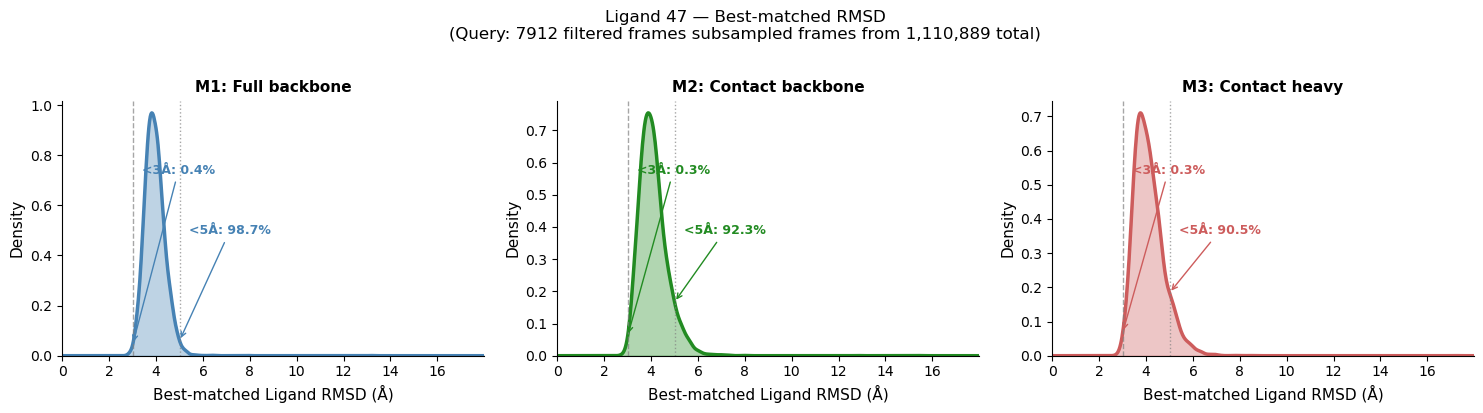

M1: Full backbone: query frame=243, RMSD=2.766 Å
M2: Contact backbone: query frame=8620, RMSD=2.741 Å
M3: Contact heavy: query frame=5898, RMSD=2.768 Å


In [23]:
results_bm = {}
for method, align_d, align_q in [
    ('M1: Full backbone',          desres_ca,   q_ca),
    ('M2: Contact backbone', align_m2_d,  align_m2_q),
    ('M3: Contact heavy',    align_m3_d,  align_m3_q),
]:
    print(f"\n{'='*55}")
    print(f"Running {method}...")
    bm, bi = fast_best_matched_rmsd(
        query_filtered, desres_sub,
        align_d, desres_lig_heavy,
        align_q, q_lig_heavy,
        label=method, batch_size=500)
    results_bm[method] = {'rmsd': bm, 'best_idx': bi}
    print(f"  Mean={bm.mean():.2f} Å, "
          f"Median={np.median(bm):.2f} Å, "
          f"<3Å={(bm<3).mean()*100:.1f}%, "
          f"<5Å={(bm<5).mean()*100:.1f}%")


print("\n" + "="*60)
print(f"{'Method':<25} {'Mean':>8} {'Median':>8} "
      f"{'<3Å':>8} {'<5Å':>8} {'N frames':>10}")
print("="*60)
for method, data in results_bm.items():
    bm = data['rmsd']
    print(f"{method:<25} "
          f"{bm.mean():>8.2f} "
          f"{np.median(bm):>8.2f} "
          f"{(bm<3).mean()*100:>7.1f}% "
          f"{(bm<5).mean()*100:>7.1f}% "
          f"{len(bm):>10}")


fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors_m  = {'M1: Full backbone':          'steelblue',
             'M2: Contact backbone': 'forestgreen',
             'M3: Contact heavy':    'indianred'}

x_max = max(data['rmsd'].max()
            for data in results_bm.values()) * 1.05
x_max = max(x_max, 8.0)
x     = np.linspace(0, x_max, 600)

for ax, (method, data) in zip(axes, results_bm.items()):
    color = colors_m[method]
    bm    = data['rmsd']
    kde   = gaussian_kde(bm, bw_method=0.2)
    y     = kde(x)
    ax.fill_between(x, y, alpha=0.35, color=color)
    ax.plot(x, y, color=color, lw=2.5)

    for thresh, ls, ypos in [(3.0,'--',0.75),(5.0,':',0.50)]:
        ax.axvline(thresh, color='gray', lw=1,
                   linestyle=ls, alpha=0.7)
        pct = (bm < thresh).mean() * 100
        ax.annotate(
            f'<{thresh:.0f}Å: {pct:.1f}%',
            xy=(thresh, kde(thresh)[0]),
            xytext=(thresh+0.4, y.max()*ypos),
            color=color, fontsize=9, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color=color, lw=1))

    ax.set_xlim(0, x_max)
    ax.set_ylim(0, None)
    ax.set_xlabel('Best-matched Ligand RMSD (Å)', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(method, fontsize=11, fontweight='bold')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.suptitle(
    f'Ligand 47 — Best-matched RMSD\n'
    f'(Query: {query_filtered.n_frames} filtered frames '
    f'subsampled frames from {desres_traj.n_frames:,} total)',
    fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig('ligand47_best_matched_final.png',
            dpi=150, bbox_inches='tight')
plt.show()

for method, data in results_bm.items():
    best_qi   = int(np.argmin(data['rmsd']))
    best_di   = int(data['best_idx'][best_qi])
    tag       = method.split(':')[0].replace(' ','')
    query_filtered[best_qi].save_pdb(
        f'ligand47_{tag}_query_best.pdb')
    desres_sub[best_di].save_pdb(
        f'ligand47_{tag}_desres_best.pdb')
    print(f"{method}: query frame={valid_indices[best_qi]}, "
          f"RMSD={data['rmsd'][best_qi]:.3f} Å")